<a href="https://colab.research.google.com/github/youssef12111/facial-emotion-recognition-ai/blob/main/Facial_Recognition_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ===== Cell 1: Setup & Imports =====

from google.colab import drive
drive.mount('/content/drive')

# Core libraries ---
import os
import numpy as np
import pandas as pd

# Image processing & visualisation ---
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning models & evaluation tools
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Paths setup
BASE = "/content/drive/MyDrive/FER_CO3519"
DATA_DIR = os.path.join(BASE, "datasets")

# dataset folders
CK_DIR = os.path.join(DATA_DIR, "CK_dataset")
JAFFE_DIR = os.path.join(DATA_DIR, "Jaffe_dataset")

print("Drive mounted and paths set.")
print("CK+ dataset folder :", CK_DIR)
print("JAFFE dataset folder:", JAFFE_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted and paths set.
CK+ dataset folder : /content/drive/MyDrive/FER_CO3519/datasets/CK_dataset
JAFFE dataset folder: /content/drive/MyDrive/FER_CO3519/datasets/Jaffe_dataset


In [ ]:
# ===== Cell 2: List images + Basic Preprocessing (grayscale + resize) =====

# Keep label names consistent across both datasets
LABEL_MAP = {
    "Angry":"angry", "angry":"angry", "anger":"angry",
    "Fear":"fear",  "fear":"fear",
    "Happy":"happy","happy":"happy",
    "Neutral":"neutral","neutral":"neutral",
    "Sad":"sad", "sad":"sad", "sadness":"sad",
    "Surprise":"surprise","surprise":"surprise",
}

# What I consider as image files
IMAGE_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")

# resize all images to this size (small = faster)
IMG_SIZE = (96, 96)

def list_images(dataset_root, split_name):
    """
    dataset_root: like CK_DIR or JAFFE_DIR
    split_name: "train" or "test"
    Returns: list of (filepath, clean_label)
    """
    split_folder = os.path.join(dataset_root, split_name)
    items = []

    if not os.path.isdir(split_folder):
        print(f"[warn] split folder not found: {split_folder}")
        return items

    # each subfolder is a class (for exmaple, happy, sad, etc.)
    for cls in sorted(os.listdir(split_folder)):
        cls_path = os.path.join(split_folder, cls)
        if not os.path.isdir(cls_path):
            continue

 # map to our standard label names
        clean_label = LABEL_MAP.get(cls, cls)

        for fname in os.listdir(cls_path):
            if fname.lower().endswith(IMAGE_EXTS):
                items.append((os.path.join(cls_path, fname), clean_label))

    return items

def read_preprocess(path, size=IMG_SIZE):
    """
    Read an image, convert to grayscale, and resize to a fixed size.
    Returns: 2D numpy array (grayscale image)
    """
    img = cv2.imread(path)
    if img is None:
        return None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img = cv2.resize(img, size, interpolation=cv2.INTER_AREA)
    return img

# quick preview helper, shows one example per class from 'train'
def preview_one_per_class(dataset_root):
    seen = set()
    items = list_images(dataset_root, "train")
    for path, label in items:
        if label in seen:
            continue
        img = read_preprocess(path)
        if img is None:
            continue
        plt.imshow(img, cmap="gray"); plt.axis("off")
        plt.title(f"{os.path.basename(dataset_root)} – {label}")
        plt.show()
        seen.add(label)
        if len(seen) >= 6:  # there are 6 emotions
            break

print("Cell 2 ready: use list_images() and read_preprocess() next.")

Cell 2 ready: use list_images() and read_preprocess() next.


In [ ]:
# ===== Cell 3: HOG Feature Extraction =====
from skimage.feature import hog

def extract_hog_features(image):
    """
    Given a preprocessed grayscale image, compute HOG features.
    Returns a 1-D numpy array (feature vector).
    """
    features = hog(
        image,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm='L2-Hys',
        transform_sqrt=True,
        feature_vector=True
    )
    return features

# loading one image and showing its HOG visualisation as a quick check
sample_items = list_images(JAFFE_DIR, "train")
if sample_items:
    path, label = sample_items[0]
    img = read_preprocess(path)
    feats = extract_hog_features(img)
    print(f"Sample image shape: {img.shape}")
    print(f"HOG feature length: {len(feats)}")
else:
    print("No images found to preview HOG features.")

Sample image shape: (96, 96)
HOG feature length: 4356


In [ ]:
# ===== Cell 4: Build JAFFE train/test feature sets =====

def build_split_features(dataset_root, split_name):
    """
    Make X (features) and y (labels) for a dataset split ('train' or 'test').
    """
    items = list_images(dataset_root, split_name)
    X_list, y_list = [], []

    for path, label in items:
        img = read_preprocess(path)           # grayscale + resize
        if img is None:
            continue
        feat = extract_hog_features(img)      # HOG vector
        X_list.append(feat)
        y_list.append(label)

    X = np.array(X_list, dtype=np.float32)
    y = np.array(y_list)
    return X, y

# run for JAFFE
print("Building JAFFE features...")
X_train_jaf, y_train_jaf = build_split_features(JAFFE_DIR, "train")
X_test_jaf,  y_test_jaf  = build_split_features(JAFFE_DIR, "test")

print("JAFFE X_train shape:", X_train_jaf.shape)
print("JAFFE X_test  shape:", X_test_jaf.shape)

# label distribution
print("\nJAFFE train label counts:")
print(pd.Series(y_train_jaf).value_counts().sort_index())
print("\nJAFFE test label counts:")
print(pd.Series(y_test_jaf).value_counts().sort_index())

Building JAFFE features...
JAFFE X_train shape: (128, 4356)
JAFFE X_test  shape: (55, 4356)

JAFFE train label counts:
angry       20
fear        22
happy       22
neutral     21
sad         22
surprise    21
Name: count, dtype: int64

JAFFE test label counts:
angry        9
fear        10
happy        9
neutral      9
sad          9
surprise     9
Name: count, dtype: int64


In [ ]:
# ===== Cell 5: Build CK+ train/test feature sets =====

print("Building CK+ features...")
X_train_ck, y_train_ck = build_split_features(CK_DIR, "train")
X_test_ck,  y_test_ck  = build_split_features(CK_DIR, "test")

print("CK+ X_train shape:", X_train_ck.shape)
print("CK+ X_test  shape:", X_test_ck.shape)

# label distribution
print("\nCK+ train label counts:")
print(pd.Series(y_train_ck).value_counts().sort_index())
print("\nCK+ test label counts:")
print(pd.Series(y_test_ck).value_counts().sort_index())

Building CK+ features...
CK+ X_train shape: (341, 4356)
CK+ X_test  shape: (143, 4356)

CK+ train label counts:
angry       40
fear        16
happy       75
neutral     86
sad         41
surprise    83
Name: count, dtype: int64

CK+ test label counts:
angry       18
fear         7
happy       30
neutral     36
sad         17
surprise    35
Name: count, dtype: int64


KNN (JAFFE) accuracy: 0.436

Classification report (JAFFE, KNN):
              precision    recall  f1-score   support

       angry       1.00      0.33      0.50         9
        fear       0.57      0.40      0.47        10
       happy       0.43      0.33      0.38         9
     neutral       0.31      0.56      0.40         9
         sad       0.27      0.44      0.33         9
    surprise       0.71      0.56      0.62         9

    accuracy                           0.44        55
   macro avg       0.55      0.44      0.45        55
weighted avg       0.55      0.44      0.45        55

Saved: /content/Figure_3b_KNN_JAFFE.png


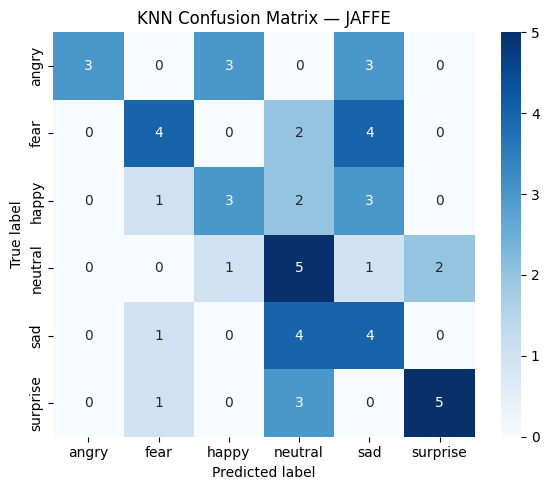

In [ ]:
# ===== Cell 6: KNN on JAFFE (train -> test) =====

# fixed order for multi-class reporting (same across all cells)
EMOTIONS = ["angry", "fear", "happy", "neutral", "sad", "surprise"]

# build the classifier (same style as we did in the lab week 5)
knn_jaf = KNeighborsClassifier(
    n_neighbors=5,
    metric='euclidean'
)

# train
knn_jaf.fit(X_train_jaf, y_train_jaf)

# predict on the test set
y_pred_jaf = knn_jaf.predict(X_test_jaf)

# metrics
acc = accuracy_score(y_test_jaf, y_pred_jaf)
print(f"KNN (JAFFE) accuracy: {acc:.3f}\n")

print("Classification report (JAFFE, KNN):")
print(classification_report(y_test_jaf, y_pred_jaf, labels=EMOTIONS, target_names=EMOTIONS, zero_division=0))

# confusion matrix visual
cm = confusion_matrix(y_test_jaf, y_pred_jaf, labels=EMOTIONS)
cm_df = pd.DataFrame(cm, index=EMOTIONS, columns=EMOTIONS)

plt.figure(figsize=(6,5))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.title("KNN Confusion Matrix — JAFFE")

# save figure as PNG for the report
plt.tight_layout()
plt.savefig("/content/Figure_3b_KNN_JAFFE.png", bbox_inches='tight', dpi=300)
print("Saved: /content/Figure_3b_KNN_JAFFE.png")

plt.show()

KNN (CK+) accuracy: 0.531

Classification report (CK+, KNN):
              precision    recall  f1-score   support

       angry       0.43      0.33      0.38        18
        fear       0.00      0.00      0.00         7
       happy       0.65      0.73      0.69        30
     neutral       0.43      0.72      0.54        36
         sad       0.38      0.18      0.24        17
    surprise       0.83      0.54      0.66        35

    accuracy                           0.53       143
   macro avg       0.45      0.42      0.42       143
weighted avg       0.54      0.53      0.52       143

Saved: /content/Figure_3b_KNN_CK+.png


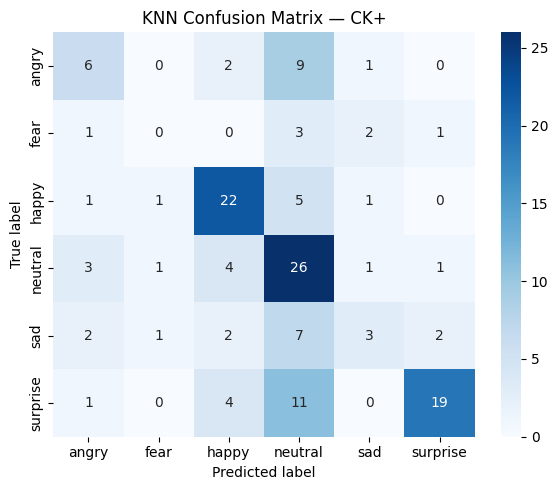

In [ ]:
# ===== Cell 7: KNN on CK+ (train -> test) =====

EMOTIONS = ["angry", "fear", "happy", "neutral", "sad", "surprise"]

knn_ck = KNeighborsClassifier(
    n_neighbors=5,
    metric='euclidean'
)

knn_ck.fit(X_train_ck, y_train_ck)
y_pred_ck = knn_ck.predict(X_test_ck)

acc_ck = accuracy_score(y_test_ck, y_pred_ck)
print(f"KNN (CK+) accuracy: {acc_ck:.3f}\n")

print("Classification report (CK+, KNN):")
print(classification_report(y_test_ck, y_pred_ck, labels=EMOTIONS, target_names=EMOTIONS, zero_division=0))

cm_ck = confusion_matrix(y_test_ck, y_pred_ck, labels=EMOTIONS)
cm_ck_df = pd.DataFrame(cm_ck, index=EMOTIONS, columns=EMOTIONS)

plt.figure(figsize=(6,5))
sns.heatmap(cm_ck_df, annot=True, fmt='d', cmap='Blues')
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.title("KNN Confusion Matrix — CK+")

# save figure as PNG for the report
plt.tight_layout()
plt.savefig("/content/Figure_3b_KNN_CK+.png", bbox_inches='tight', dpi=300)
print("Saved: /content/Figure_3b_KNN_CK+.png")

plt.show()

SVM (JAFFE) accuracy: 0.473

Classification report (JAFFE, SVM):
              precision    recall  f1-score   support

       angry       1.00      0.78      0.88         9
        fear       0.21      0.60      0.32        10
       happy       1.00      0.22      0.36         9
     neutral       1.00      0.44      0.62         9
         sad       0.36      0.44      0.40         9
    surprise       1.00      0.33      0.50         9

    accuracy                           0.47        55
   macro avg       0.76      0.47      0.51        55
weighted avg       0.75      0.47      0.51        55

Saved: /content/Figure_3c_SVM_JAFFE.png


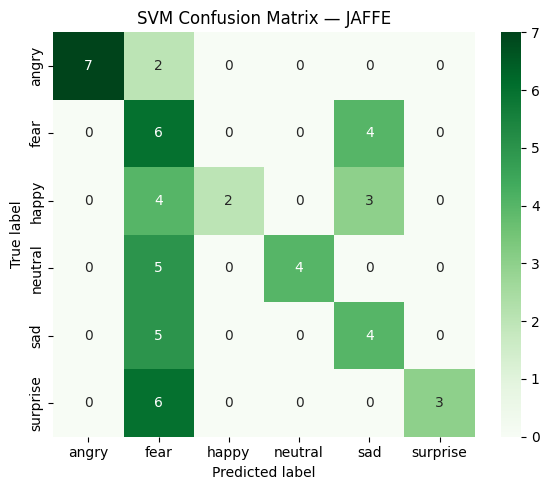

In [ ]:
# ===== Cell 8: SVM on JAFFE =====

EMOTIONS = ["angry", "fear", "happy", "neutral", "sad", "surprise"]

# define model
svm_jaf = SVC(kernel='linear', C=1.0, random_state=42)

# train
svm_jaf.fit(X_train_jaf, y_train_jaf)

# predict
y_pred_svm_jaf = svm_jaf.predict(X_test_jaf)

# metrics
acc_svm_jaf = accuracy_score(y_test_jaf, y_pred_svm_jaf)
print(f"SVM (JAFFE) accuracy: {acc_svm_jaf:.3f}\n")

print("Classification report (JAFFE, SVM):")
print(classification_report(y_test_jaf, y_pred_svm_jaf, labels=EMOTIONS, target_names=EMOTIONS, zero_division=0))

cm_svm_jaf = confusion_matrix(y_test_jaf, y_pred_svm_jaf, labels=EMOTIONS)
cm_svm_jaf_df = pd.DataFrame(cm_svm_jaf, index=EMOTIONS, columns=EMOTIONS)

plt.figure(figsize=(6,5))
sns.heatmap(cm_svm_jaf_df, annot=True, fmt='d', cmap='Greens')
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.title("SVM Confusion Matrix — JAFFE")

# save figure as PNG for the report
plt.tight_layout()
plt.savefig("/content/Figure_3c_SVM_JAFFE.png", bbox_inches='tight', dpi=300)
print("Saved: /content/Figure_3c_SVM_JAFFE.png")

plt.show()

SVM (CK+) accuracy: 0.615

Classification Report — CK+ (SVM):
              precision    recall  f1-score   support

       angry       0.60      0.33      0.43        18
        fear       0.00      0.00      0.00         7
       happy       0.87      0.87      0.87        30
     neutral       0.45      0.67      0.54        36
         sad       0.41      0.41      0.41        17
    surprise       0.78      0.71      0.75        35

    accuracy                           0.62       143
   macro avg       0.52      0.50      0.50       143
weighted avg       0.61      0.62      0.60       143

Saved: /content/Figure_3c_SVM_CK+.png


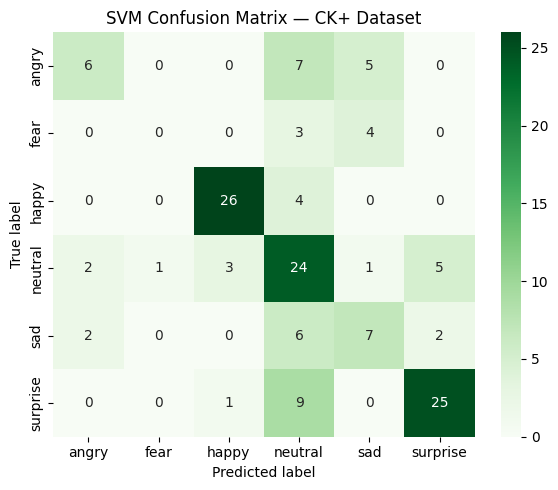

In [ ]:
# ===== Cell 9: SVM on CK+ dataset =====

EMOTIONS = ["angry", "fear", "happy", "neutral", "sad", "surprise"]

# create the model
svm_model_ck = SVC(kernel='linear', C=1.0, random_state=42)

# train on CK+ train set
svm_model_ck.fit(X_train_ck, y_train_ck)

# predict on CK+ test set
y_pred_ck_svm = svm_model_ck.predict(X_test_ck)

# evaluate
svm_ck_accuracy = accuracy_score(y_test_ck, y_pred_ck_svm)
print(f"SVM (CK+) accuracy: {svm_ck_accuracy:.3f}\n")

print("Classification Report — CK+ (SVM):")
print(classification_report(y_test_ck, y_pred_ck_svm,
                            labels=EMOTIONS, target_names=EMOTIONS, zero_division=0))

# confusion matrix
cm_ck_svm = confusion_matrix(y_test_ck, y_pred_ck_svm, labels=EMOTIONS)
cm_ck_svm_df = pd.DataFrame(cm_ck_svm, index=EMOTIONS, columns=EMOTIONS)

plt.figure(figsize=(6,5))
sns.heatmap(cm_ck_svm_df, annot=True, fmt='d', cmap='Greens')
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.title("SVM Confusion Matrix — CK+ Dataset")

# save figure as PNG for the report
plt.tight_layout()
plt.savefig("/content/Figure_3c_SVM_CK+.png", bbox_inches='tight', dpi=300)
print("Saved: /content/Figure_3c_SVM_CK+.png")

plt.show()

,Model,Accuracy
2,CK+_KNN,0.531469
3,CK+_SVM,0.615385
0,JAFFE_KNN,0.436364
1,JAFFE_SVM,0.472727


Saved: /content/Figure_4.png


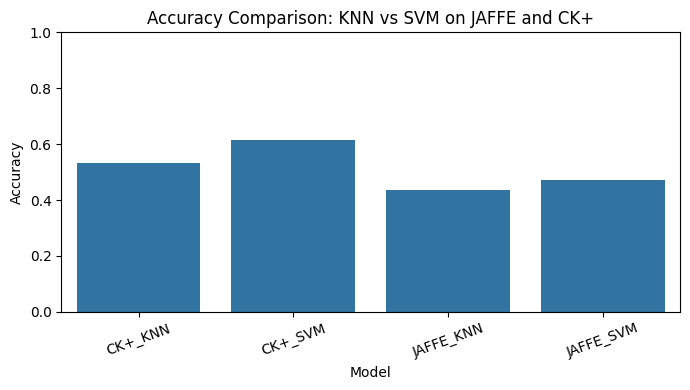

In [ ]:
# ===== Cell 10: Simple comparison table & bar chart =====
results = {
    "JAFFE_KNN":  accuracy_score(y_test_jaf, y_pred_jaf),
    "JAFFE_SVM":  accuracy_score(y_test_jaf, y_pred_svm_jaf),
    "CK+_KNN":    accuracy_score(y_test_ck,  y_pred_ck),
    "CK+_SVM":    accuracy_score(y_test_ck,  y_pred_ck_svm),
}

# neat table
res_df = pd.DataFrame(list(results.items()), columns=["Model", "Accuracy"]).sort_values("Model")
display(res_df)

# quick bar chart
plt.figure(figsize=(7,4))
sns.barplot(x="Model", y="Accuracy", data=res_df)
plt.ylim(0,1)
plt.title("Accuracy Comparison: KNN vs SVM on JAFFE and CK+")
plt.xticks(rotation=20)

# save figure as PNG for the report
plt.tight_layout()
plt.savefig("/content/Figure_4.png", bbox_inches='tight', dpi=300)
print("Saved: /content/Figure_4.png")

plt.show()

In [ ]:
# ===== Cell 11: Tiny hyperparameter tuning with 3-fold CV (JAFFE + CK+) =====
from sklearn.model_selection import GridSearchCV

EMOTIONS = ["angry", "fear", "happy", "neutral", "sad", "surprise"]

# Utility function to tune and evaluate both models on a given dataset
def tune_models(X_train, y_train, X_test, y_test, dataset_name):
    print(f"\n=== {dataset_name.upper()} Dataset ===")

    # KNN Grid Search
    knn_grid = GridSearchCV(
        KNeighborsClassifier(metric='euclidean'),
        param_grid={"n_neighbors": [3, 5, 7, 9]},
        cv=3, scoring="accuracy", n_jobs=-1
    )
    knn_grid.fit(X_train, y_train)
    best_knn = knn_grid.best_estimator_
    knn_test_acc = accuracy_score(y_test, best_knn.predict(X_test))
    print(f"KNN best params: {knn_grid.best_params_} | CV: {knn_grid.best_score_:.3f} | Test: {knn_test_acc:.3f}")

    # SVM Grid Search
    svm_grid = GridSearchCV(
        SVC(kernel='linear', random_state=42),
        param_grid={"C": [0.1, 1, 3, 10]},
        cv=3, scoring="accuracy", n_jobs=-1
    )
    svm_grid.fit(X_train, y_train)
    best_svm = svm_grid.best_estimator_
    svm_test_acc = accuracy_score(y_test, best_svm.predict(X_test))
    print(f"SVM best params: {svm_grid.best_params_} | CV: {svm_grid.best_score_:.3f} | Test: {svm_test_acc:.3f}")

    return best_knn, best_svm, knn_test_acc, svm_test_acc

# Run tuning for both datasets
best_knn_jaffe, best_svm_jaffe, acc_knn_jaffe, acc_svm_jaffe = tune_models(
    X_train_jaf, y_train_jaf, X_test_jaf, y_test_jaf, "JAFFE"
)

best_knn_ck, best_svm_ck, acc_knn_ck, acc_svm_ck = tune_models(
    X_train_ck, y_train_ck, X_test_ck, y_test_ck, "CK+"
)

# Summary table
tuning_results = pd.DataFrame({
    "Dataset": ["JAFFE", "CK+"],
    "Best KNN Test Acc": [acc_knn_jaffe, acc_knn_ck],
    "Best SVM Test Acc": [acc_svm_jaffe, acc_svm_ck]
})

print("\n=== Summary of Tuned Model Accuracies ===")
display(tuning_results)



=== JAFFE Dataset ===
KNN best params: {'n_neighbors': 3} | CV: 0.532 | Test: 0.436
SVM best params: {'C': 1} | CV: 0.837 | Test: 0.473

=== CK+ Dataset ===
KNN best params: {'n_neighbors': 9} | CV: 0.595 | Test: 0.559
SVM best params: {'C': 0.1} | CV: 0.645 | Test: 0.629

=== Summary of Tuned Model Accuracies ===


,Dataset,Best KNN Test Acc,Best SVM Test Acc
0,JAFFE,0.436364,0.472727
1,CK+,0.559441,0.629371


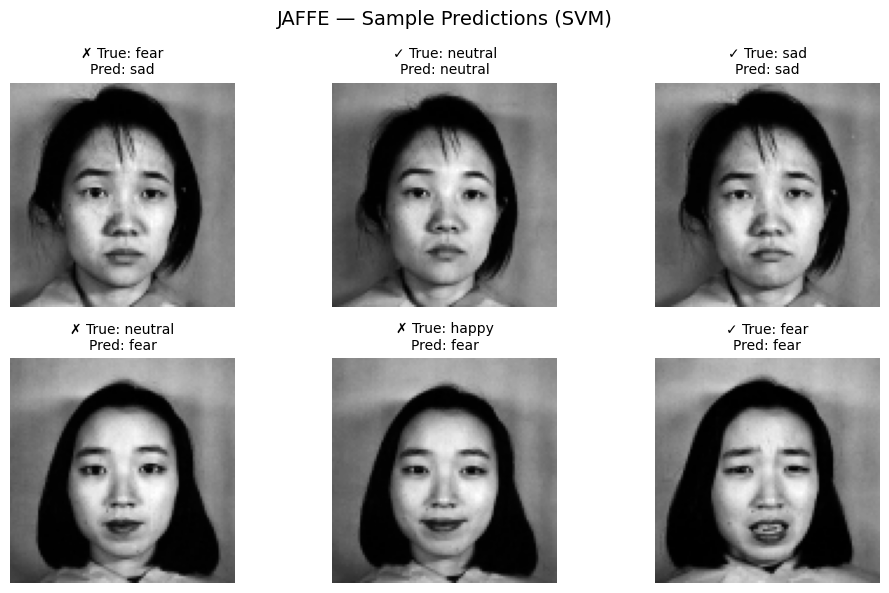

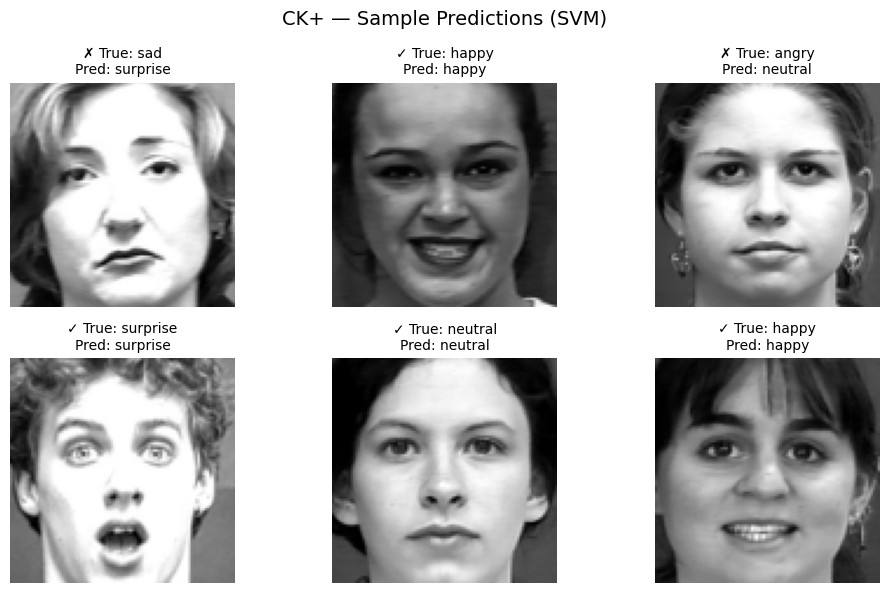

In [ ]:
# ===== Cell 12: Show sample predictions with tuned models =====
import random

def show_sample_predictions(dataset_root, X_test, y_test, model, n=6, title="Predictions"):
    """
    Displays a few random test images with their true and predicted emotion labels.
    A ✓ means correct, ✗ means wrong.
    """
    items = list_images(dataset_root, "test")
    idxs = random.sample(range(len(items)), k=min(n, len(items)))

    plt.figure(figsize=(10, 6))
    for i, idx in enumerate(idxs, 1):
        path, true_label = items[idx]
        img = read_preprocess(path)
        feats = extract_hog_features(img).reshape(1, -1)
        pred_label = model.predict(feats)[0]

        plt.subplot(2, (n+1)//2, i)
        plt.imshow(img, cmap='gray')
        plt.axis('off')
        ok = "✓" if pred_label == true_label else "✗"
        plt.title(f"{ok} True: {true_label}\nPred: {pred_label}", fontsize=10)
    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

# JAFFE predictions (tuned SVM)
show_sample_predictions(JAFFE_DIR, X_test_jaf, y_test_jaf,
                        best_svm_jaffe, n=6, title="JAFFE — Sample Predictions (SVM)")

#  CK+ predictions (tuned SVM)
show_sample_predictions(CK_DIR, X_test_ck, y_test_ck,
                        best_svm_ck, n=6, title="CK+ — Sample Predictions (SVM)")


In [ ]:
# ===== Enhancement Stage: Data Augmentation (Horizontal Flip) Train-time  for JAFFE & CK+ =====


import numpy as np
import cv2

def build_split_features_with_flip(dataset_root, split_name, do_flip=False):
    """
    Builds X, y for a dataset split. If do_flip=True, we add a horizontally flipped
    version of each image (train augmentation). Test split should keep do_flip=False.
    """
    items = list_images(dataset_root, split_name)
    X_list, y_list = [], []

    for path, label in items:
        img = read_preprocess(path)
        if img is None:
            continue

        # original
        feat = extract_hog_features(img)
        X_list.append(feat)
        y_list.append(label)

        # augmented (flip)
        if do_flip:
            img_flip = cv2.flip(img, 1)  # 1 = horizontal flip
            feat_flip = extract_hog_features(img_flip)
            X_list.append(feat_flip)
            y_list.append(label)  # same label

    X = np.array(X_list, dtype=np.float32)
    y = np.array(y_list)
    return X, y

# Rebuild TRAIN sets with flip; TEST stays as-is
print("Rebuilding JAFFE with flip on TRAIN...")
X_train_jaffe_aug, y_train_jaffe_aug = build_split_features_with_flip(JAFFE_DIR, "train", do_flip=True)
X_test_jaffe_aug,  y_test_jaffe_aug  = X_test_jaf, y_test_jaf

print("Rebuilding CK+ with flip on TRAIN...")
X_train_ck_aug, y_train_ck_aug = build_split_features_with_flip(CK_DIR, "train", do_flip=True)
X_test_ck_aug,  y_test_ck_aug  = X_test_ck, y_test_ck

# Shapes before vs after (for sanity)
print("\nJAFFE train: original -> augmented:", X_train_jaf.shape, "->", X_train_jaffe_aug.shape)
print("JAFFE test (unchanged):", X_test_jaffe_aug.shape)

print("\nCK+   train: original -> augmented:", X_train_ck.shape, "->", X_train_ck_aug.shape)
print("CK+   test (unchanged):", X_test_ck_aug.shape)


Rebuilding JAFFE with flip on TRAIN...
Rebuilding CK+ with flip on TRAIN...

JAFFE train: original -> augmented: (128, 4356) -> (256, 4356)
JAFFE test (unchanged): (55, 4356)

CK+   train: original -> augmented: (341, 4356) -> (682, 4356)
CK+   test (unchanged): (143, 4356)


JAFFE (aug+scaled)  KNN acc: 0.400 | SVM-linear acc: 0.600
CK+   (aug+scaled)  KNN acc: 0.455 | SVM-linear acc: 0.629
Saved: /content/Figure_5a.png


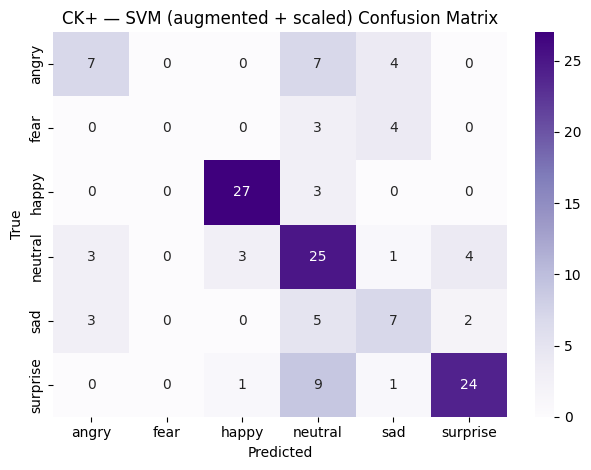

In [ ]:
# ===== Enhancement Stage: StandardScaler + Retrain (using augmented train sets) =====
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

EMOTIONS = ["angry","fear","happy","neutral","sad","surprise"]

# Pipelines: Scaler -> Model (clean and safe)
knn_pipe_jaffe = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5, metric='euclidean'))
svm_lin_pipe_jaffe = make_pipeline(StandardScaler(), SVC(kernel='linear', C=1.0, random_state=42))

knn_pipe_ck   = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5, metric='euclidean'))
svm_lin_pipe_ck   = make_pipeline(StandardScaler(), SVC(kernel='linear', C=0.1, random_state=42))  # use tuned C for CK+

# Train on AUGMENTED train sets, evaluate on ORIGINAL test sets
# JAFFE
knn_pipe_jaffe.fit(X_train_jaffe_aug, y_train_jaffe_aug)
svm_lin_pipe_jaffe.fit(X_train_jaffe_aug, y_train_jaffe_aug)

y_pred_knn_jaffe_aug = knn_pipe_jaffe.predict(X_test_jaffe_aug)
y_pred_svm_jaffe_aug = svm_lin_pipe_jaffe.predict(X_test_jaffe_aug)

acc_knn_jaffe_aug = accuracy_score(y_test_jaffe_aug, y_pred_knn_jaffe_aug)
acc_svm_jaffe_aug = accuracy_score(y_test_jaffe_aug, y_pred_svm_jaffe_aug)

print(f"JAFFE (aug+scaled)  KNN acc: {acc_knn_jaffe_aug:.3f} | SVM-linear acc: {acc_svm_jaffe_aug:.3f}")

# CK+
knn_pipe_ck.fit(X_train_ck_aug, y_train_ck_aug)
svm_lin_pipe_ck.fit(X_train_ck_aug, y_train_ck_aug)

y_pred_knn_ck_aug = knn_pipe_ck.predict(X_test_ck_aug)
y_pred_svm_ck_aug = svm_lin_pipe_ck.predict(X_test_ck_aug)

acc_knn_ck_aug = accuracy_score(y_test_ck_aug, y_pred_knn_ck_aug)
acc_svm_ck_aug = accuracy_score(y_test_ck_aug, y_pred_svm_ck_aug)

print(f"CK+   (aug+scaled)  KNN acc: {acc_knn_ck_aug:.3f} | SVM-linear acc: {acc_svm_ck_aug:.3f}")

# a quick confusion matrix for best performer on CK+
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test_ck_aug, y_pred_svm_ck_aug, labels=EMOTIONS)
sns.heatmap(pd.DataFrame(cm, index=EMOTIONS, columns=EMOTIONS), annot=True, fmt='d', cmap='Purples')
plt.title("CK+ — SVM (augmented + scaled) Confusion Matrix")
plt.ylabel("True")
plt.xlabel("Predicted")

# save figure as PNG for the report
plt.tight_layout()
plt.savefig("/content/Figure_5a.png", bbox_inches='tight', dpi=300)
print("Saved: /content/Figure_5a.png")
plt.show()

In [ ]:
# ===== Enhancement Summary: Before vs After (Augmentation + Scaling) =====
import pandas as pd

comparison_data = {
    "Dataset": ["JAFFE", "CK+"],
    "KNN (Before)": [0.436, 0.531],
    "KNN (After)":  [0.400, 0.455],
    "SVM (Before)": [0.473, 0.629],
    "SVM (After)":  [0.600, 0.629]
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df["KNN Δ"] = comparison_df["KNN (After)"] - comparison_df["KNN (Before)"]
comparison_df["SVM Δ"] = comparison_df["SVM (After)"] - comparison_df["SVM (Before)"]

print("=== Model Performance Comparison (Before vs After Augmentation + Scaling) ===")
display(comparison_df)

=== Model Performance Comparison (Before vs After Augmentation + Scaling) ===


,Dataset,KNN (Before),KNN (After),SVM (Before),SVM (After),KNN Δ,SVM Δ
0,JAFFE,0.436,0.400,0.473,0.600,-0.036,0.127
1,CK+,0.531,0.455,0.629,0.629,-0.076,0.000
